Week 6 — Telco Customer Churn (IBM): Fine-Tuning and Ensembles

This notebook builds on the Week 5 shortlist. It runs the same self-contained pipeline (obtain, prepare), retrains the shortlisted models as a baseline, then fine-tunes them with GridSearchCV and RandomizedSearchCV, selects a decision threshold for the class imbalance, and combines the models with ensemble methods (stacking and voting; Gradient Boosting is itself a boosting ensemble).
The goal is to improve on the Week 5 default models and to narrow the gap to IBM's Churn Score benchmark.
The classes are imbalanced (about 26.5% churn), so models are tuned for ROC-AUC (a threshold-independent ranking measure) and then given an operating threshold chosen for F1.

Obtain and prepare the data, exactly as in Week 4/5: download, fix Total Charges, engineer three features, drop identifier/constant/leakage columns, split 80/20 stratified, then one-hot encode and scale with a ColumnTransformer fit on the training set only.

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
import kagglehub

path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")
df = pd.read_excel(os.path.join(path, "Telco_customer_churn.xlsx"))
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
print(df.shape)

(7043, 33)


In [3]:
churn_score_benchmark = df["Churn Score"].copy()   # IBM's propensity score, kept aside

DROP_COLS = [
    "Count", "Country", "State",
    "CustomerID", "City", "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Churn Label", "Churn Score", "Churn Reason", "CLTV",
    "Churn Value",
]
ADDON_COLS = ["Online Security", "Online Backup", "Device Protection",
              "Tech Support", "Streaming TV", "Streaming Movies"]
NUMERIC_FEATURES = ["Tenure Months", "Monthly Charges", "Total Charges", "Num_Addon_Services"]
PASSTHROUGH_FEATURES = ["AutoPay", "IsNewCustomer"]

def add_features(data):
    data = data.copy()
    data["Num_Addon_Services"] = (data[ADDON_COLS] == "Yes").sum(axis=1)
    data["AutoPay"] = data["Payment Method"].str.contains("automatic", case=False).astype(int)
    data["IsNewCustomer"] = (data["Tenure Months"] <= 6).astype(int)
    return data

def clean_data(data):
    data = data.copy()
    data["Total Charges"] = pd.to_numeric(data["Total Charges"], errors="coerce").fillna(0)
    return data.drop(columns=DROP_COLS)

def make_Xy(data):
    return clean_data(add_features(data)), data["Churn Value"]

In [4]:
X_all, y_all = make_Xy(df)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

categorical_features = [c for c in X_train_raw.columns
                        if c not in NUMERIC_FEATURES + PASSTHROUGH_FEATURES]
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False), categorical_features),
    ("bin", "passthrough", PASSTHROUGH_FEATURES),
])

X_train = preprocessor.fit_transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)
y_train = y_train.to_numpy()
y_test  = y_test.to_numpy()
feature_names = preprocessor.get_feature_names_out()
churn_score_test = churn_score_benchmark.loc[X_test_raw.index].to_numpy()

print("X_train:", X_train.shape, " X_test:", X_test.shape, " features:", len(feature_names))

X_train: (5634, 43)  X_test: (1409, 43)  features: 43


A small helper scores a model on the test set, and the results are collected as tuning and ensembling proceed. The baseline is the Week 5 shortlist at default settings, plus IBM's Churn Score as the benchmark to chase.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

def scores_from(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

def evaluate(name, model, threshold=0.5):
    proba = scores_from(model, X_test)
    pred = (proba >= threshold).astype(int)
    return pd.Series({
        "accuracy":  accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall":    recall_score(y_test, pred, zero_division=0),
        "f1":        f1_score(y_test, pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_test, proba),
    }, name=name)

results = []

for name, model in [
    ("LogReg (default)", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("SVM (default)",    SVC(random_state=RANDOM_STATE)),
    ("GBoost (default)", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
]:
    model.fit(X_train, y_train)
    results.append(evaluate(name, model))

# IBM benchmark (ranking only)
bench_auc = roc_auc_score(y_test, churn_score_test)
print("IBM Churn Score ROC-AUC:", round(bench_auc, 3))
pd.DataFrame(results).round(3)

IBM Churn Score ROC-AUC: 0.943


,accuracy,precision,recall,f1,roc_auc
LogReg (default),0.806,0.659,0.553,0.602,0.853
SVM (default),0.798,0.718,0.396,0.510,0.812
GBoost (default),0.800,0.642,0.556,0.596,0.846


Fine-tuning. Each model is searched with five-fold stratified cross-validation, scored on ROC-AUC so the search improves ranking quality independently of any threshold. class_weight is included in the search grids so the imbalance can be addressed directly. Logistic Regression uses an exhaustive GridSearchCV; the Support Vector Machine and Gradient Boosting use RandomizedSearchCV over larger spaces to keep the search affordable.

In [6]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
searches = {}

In [7]:
# Logistic Regression - exhaustive GridSearchCV
lr_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"],
    "solver": ["lbfgs", "liblinear"],
}
gs_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                     lr_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
gs_lr.fit(X_train, y_train)
searches["LogReg (tuned)"] = gs_lr
print("LogReg best CV ROC-AUC:", round(gs_lr.best_score_, 4))
print("LogReg best params:", gs_lr.best_params_)

LogReg best CV ROC-AUC: 0.8608
LogReg best params: {'C': 1, 'class_weight': None, 'solver': 'lbfgs'}


In [8]:
# Support Vector Machine - RandomizedSearchCV
svm_dist = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "class_weight": [None, "balanced"],
}
rs_svm = RandomizedSearchCV(SVC(random_state=RANDOM_STATE), svm_dist, n_iter=8,
                            scoring="roc_auc", cv=cv, n_jobs=-1, random_state=RANDOM_STATE)
rs_svm.fit(X_train, y_train)
searches["SVM (tuned)"] = rs_svm
print("SVM best CV ROC-AUC:", round(rs_svm.best_score_, 4))
print("SVM best params:", rs_svm.best_params_)

SVM best CV ROC-AUC: 0.8482
SVM best params: {'gamma': 0.01, 'class_weight': 'balanced', 'C': 100}


In [9]:
# Gradient Boosting - RandomizedSearchCV
gb_dist = {
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "max_leaf_nodes": [15, 31, 63],
    "max_depth": [None, 3, 6],
    "l2_regularization": [0.0, 0.1, 1.0],
    "max_iter": [150, 300],
    "min_samples_leaf": [20, 50],
}
rs_gb = RandomizedSearchCV(HistGradientBoostingClassifier(random_state=RANDOM_STATE), gb_dist,
                           n_iter=20, scoring="roc_auc", cv=cv, n_jobs=-1, random_state=RANDOM_STATE)
rs_gb.fit(X_train, y_train)
searches["GBoost (tuned)"] = rs_gb
print("GBoost best CV ROC-AUC:", round(rs_gb.best_score_, 4))
print("GBoost best params:", rs_gb.best_params_)

GBoost best CV ROC-AUC: 0.8639
GBoost best params: {'min_samples_leaf': 50, 'max_leaf_nodes': 31, 'max_iter': 150, 'max_depth': 3, 'learning_rate': 0.05, 'l2_regularization': 0.1}


In [10]:
# Evaluate the tuned models on the test set
tuned = {name: s.best_estimator_ for name, s in searches.items()}
for name, model in tuned.items():
    results.append(evaluate(name, model))
pd.DataFrame(results).round(3)

,accuracy,precision,recall,f1,roc_auc
LogReg (default),0.806,0.659,0.553,0.602,0.853
SVM (default),0.798,0.718,0.396,0.510,0.812
GBoost (default),0.800,0.642,0.556,0.596,0.846
LogReg (tuned),0.806,0.659,0.553,0.602,0.853
SVM (tuned),0.780,0.567,0.722,0.635,0.839
GBoost (tuned),0.807,0.668,0.543,0.599,0.856


Choosing an operating threshold. Tuning for ROC-AUC optimizes ranking, but the model still needs a cut-off to turn probabilities into keep/flag decisions. The best-ranking tuned model's out-of-fold probabilities on the training set are used to pick the threshold that maximizes F1, so the choice is made without touching the test set. That fixed threshold is then applied to the test set.

Best-ranking tuned model: GBoost (tuned)
Threshold maximizing out-of-fold F1: 0.36


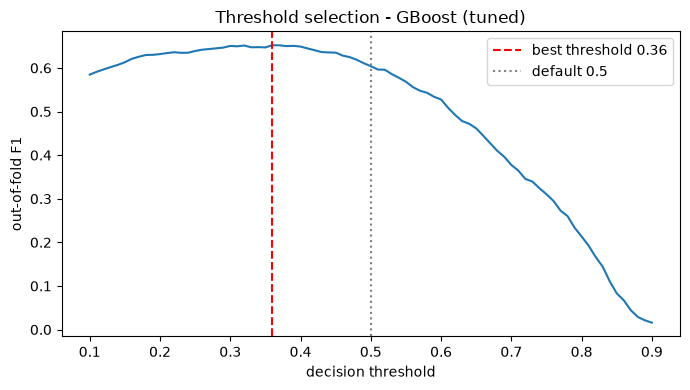

In [11]:
from sklearn.model_selection import cross_val_predict

best_name = max(searches, key=lambda n: searches[n].best_score_)
best_model = tuned[best_name]
print("Best-ranking tuned model:", best_name)

# Out-of-fold probabilities on the training set (leakage-free threshold selection)
oof_proba = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
f1s = [f1_score(y_train, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_t = thresholds[int(np.argmax(f1s))]
print("Threshold maximizing out-of-fold F1:", round(best_t, 3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1s)
ax.axvline(best_t, color="red", linestyle="--", label=f"best threshold {best_t:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="default 0.5")
ax.set_xlabel("decision threshold"); ax.set_ylabel("out-of-fold F1")
ax.set_title(f"Threshold selection - {best_name}")
ax.legend()
plt.tight_layout(); plt.show()

In [12]:
# Apply the chosen threshold to the test set
results.append(evaluate(f"{best_name} + threshold", best_model, threshold=best_t))
pd.DataFrame(results).round(3)

,accuracy,precision,recall,f1,roc_auc
LogReg (default),0.806,0.659,0.553,0.602,0.853
SVM (default),0.798,0.718,0.396,0.510,0.812
GBoost (default),0.800,0.642,0.556,0.596,0.846
LogReg (tuned),0.806,0.659,0.553,0.602,0.853
SVM (tuned),0.780,0.567,0.722,0.635,0.839
GBoost (tuned),0.807,0.668,0.543,0.599,0.856
GBoost (tuned) + threshold,0.784,0.574,0.719,0.638,0.856


Ensembles. Stacking trains the three tuned models as base learners and a logistic-regression meta-learner that learns how to weight their probabilities, using internal cross-validation so the meta-learner never sees a base model's training predictions. A soft-voting ensemble averages the probabilities of the probability-capable models (Logistic Regression, Gradient Boosting, and a Random Forest) as a simpler alternative. Gradient Boosting itself is already a boosting ensemble, so it represents that family.

In [13]:
from sklearn.ensemble import StackingClassifier, VotingClassifier

stack = StackingClassifier(
    estimators=[("lr", tuned["LogReg (tuned)"]),
                ("svm", tuned["SVM (tuned)"]),
                ("gb", tuned["GBoost (tuned)"])],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=cv, n_jobs=-1,
)
stack.fit(X_train, y_train)
results.append(evaluate("Stacking", stack))

vote = VotingClassifier(
    estimators=[("lr", tuned["LogReg (tuned)"]),
                ("gb", tuned["GBoost (tuned)"]),
                ("rf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))],
    voting="soft", n_jobs=-1,
)
vote.fit(X_train, y_train)
results.append(evaluate("Voting (soft)", vote))

pd.DataFrame(results).round(3)

,accuracy,precision,recall,f1,roc_auc
LogReg (default),0.806,0.659,0.553,0.602,0.853
SVM (default),0.798,0.718,0.396,0.510,0.812
GBoost (default),0.800,0.642,0.556,0.596,0.846
LogReg (tuned),0.806,0.659,0.553,0.602,0.853
SVM (tuned),0.780,0.567,0.722,0.635,0.839
GBoost (tuned),0.807,0.668,0.543,0.599,0.856
GBoost (tuned) + threshold,0.784,0.574,0.719,0.638,0.856
Stacking,0.799,0.633,0.578,0.604,0.855
Voting (soft),0.806,0.662,0.551,0.601,0.854


Final comparison. All models on the test set, sorted by ROC-AUC, with IBM's Churn Score as the benchmark line.

In [14]:
compare = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
compare.loc["IBM Churn Score"] = [np.nan, np.nan, np.nan, np.nan, bench_auc]
compare.round(3)

,accuracy,precision,recall,f1,roc_auc
GBoost (tuned),0.807,0.668,0.543,0.599,0.856
GBoost (tuned) + threshold,0.784,0.574,0.719,0.638,0.856
Stacking,0.799,0.633,0.578,0.604,0.855
Voting (soft),0.806,0.662,0.551,0.601,0.854
LogReg (default),0.806,0.659,0.553,0.602,0.853
LogReg (tuned),0.806,0.659,0.553,0.602,0.853
GBoost (default),0.800,0.642,0.556,0.596,0.846
SVM (tuned),0.780,0.567,0.722,0.635,0.839
SVM (default),0.798,0.718,0.396,0.510,0.812
IBM Churn Score,NaN,NaN,NaN,NaN,0.943


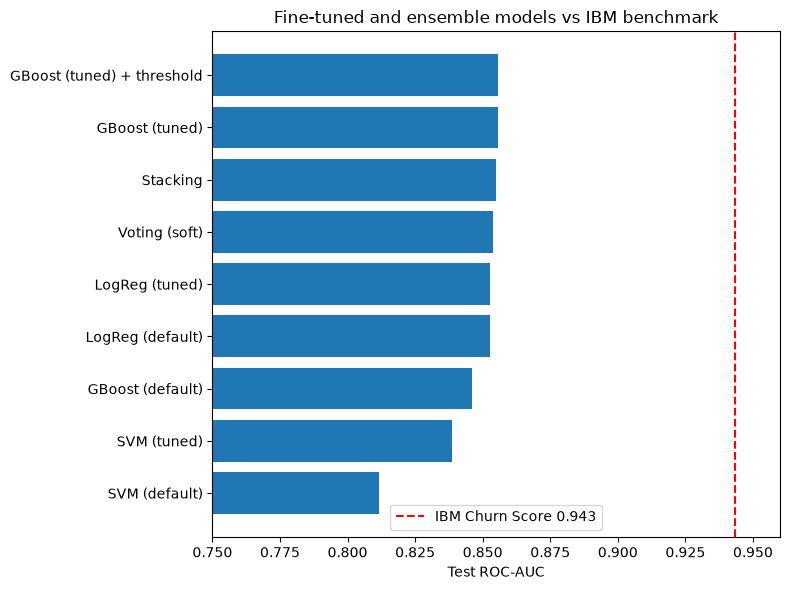

In [15]:
plot_df = pd.DataFrame(results).sort_values("roc_auc")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_df.index, plot_df["roc_auc"])
ax.axvline(bench_auc, color="red", linestyle="--", label=f"IBM Churn Score {bench_auc:.3f}")
ax.set_xlabel("Test ROC-AUC"); ax.set_xlim(0.75, 0.96)
ax.set_title("Fine-tuned and ensemble models vs IBM benchmark")
ax.legend()
plt.tight_layout(); plt.show()

Conclusion.
Fine-tuning produced modest gains in ranking quality: the best cross-validated ROC-AUC rose from the Week 5 leader's 0.85 to 0.864 for Gradient Boosting, whose tuned model also posted the best test ROC-AUC (0.856). Logistic Regression was already near-optimal, so its tuned settings matched the default.
The larger gains were in the operating metrics. Adding class_weight='balanced' turned the Support Vector Machine from a low-recall model (recall 0.40, F1 0.51) into a high-recall one (recall 0.72, F1 0.64), and choosing a decision threshold of 0.36 for the tuned Gradient Boosting raised its F1 from 0.60 at the default 0.50 to 0.64, lifting recall to 0.72 while precision fell to 0.57. This confirms the Week 5 point that the threshold, not just the model, sets the precision-recall trade.
The ensembles did not beat the best single tuned model: stacking (ROC-AUC 0.855) and soft voting (0.854) landed essentially level with the tuned Gradient Boosting (0.856). On this dataset the shortlisted models make similar enough ranking errors that combining them adds little, which is itself an honest result worth reporting.
IBM's Churn Score (ROC-AUC 0.943) remains well ahead of every model, and fine-tuning narrowed the gap only slightly. This is expected, because the Churn Score is itself the output of a model IBM built with information not available here.
The recommended model to carry into the Week 7 presentation is the tuned Gradient Boosting at a 0.36 threshold: it has the best ranking (ROC-AUC 0.856) and, at that operating point, catches about 72% of churners at an F1 of 0.64, matching the business goal of flagging likely churners for retention.